In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# For reproducibility
np.random.seed(42)


## 1. Logit-Normal Distribution

In [13]:
def pdf_normal(x):
    """Standard Normal PDF."""
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x**2)

def pdf_logistic(y):
    """PDF of Y = 1 / (1 + exp(-X)), X ~ N(0,1)."""
    # 0 < y < 1
    # x = log(y/(1-y)), dx/dy = 1 / [y(1-y)]
    # p_Y(y) = p_X(logit(y)) * (1 / [y(1-y)])
    x = np.log(y / (1.0 - y))
    return pdf_normal(x) * (1.0 / (y * (1.0 - y)))


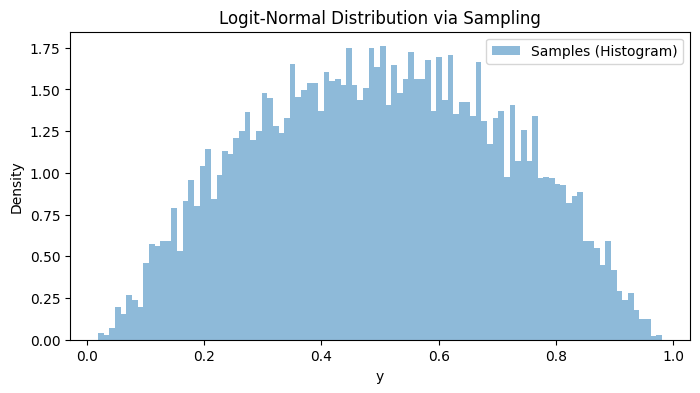

In [14]:
x_samples = np.random.randn(10000)

# Transform: Y = 1 / (1 + exp(-X))
y_samples_logistic = 1.0 / (1.0 + np.exp(-x_samples))

# Plot histogram
plt.figure(figsize=(8, 4))
counts, bins, _ = plt.hist(y_samples_logistic, bins=100, density=True, alpha=0.5, label='Samples (Histogram)')
plt.title('Logit-Normal Distribution via Sampling')
plt.xlabel('y')
plt.ylabel('Density')
plt.legend()
plt.show()

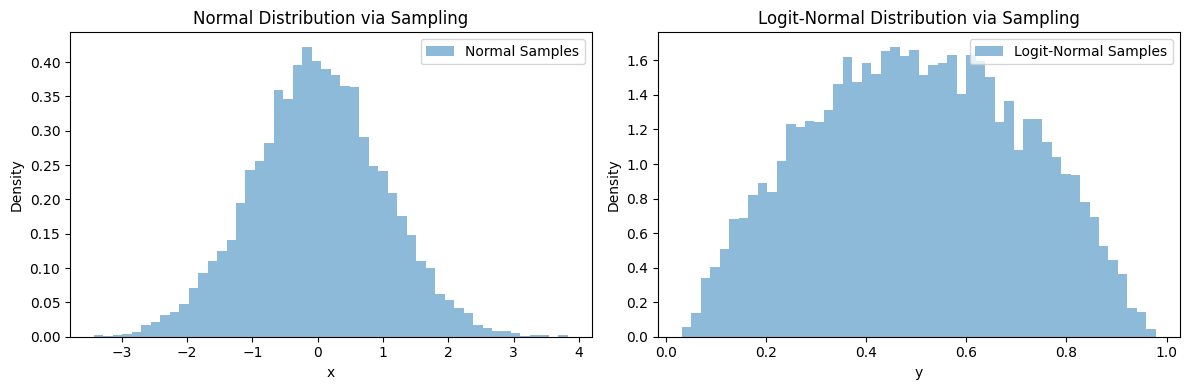

In [30]:
x_samples = np.random.randn(10000)

# Transform: Y = 1 / (1 + exp(-X))
y_samples_logistic = 1.0 / (1.0 + np.exp(-x_samples))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

# Plot histogram
axes[0].hist(x_samples, bins=50, density=True, alpha=0.5, label='Normal Samples')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_title('Normal Distribution via Sampling')

axes[1].hist(y_samples_logistic, bins=50, density=True, alpha=0.5, label='Logit-Normal Samples')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_title('Logit-Normal Distribution via Sampling')

plt.tight_layout()
plt.show()

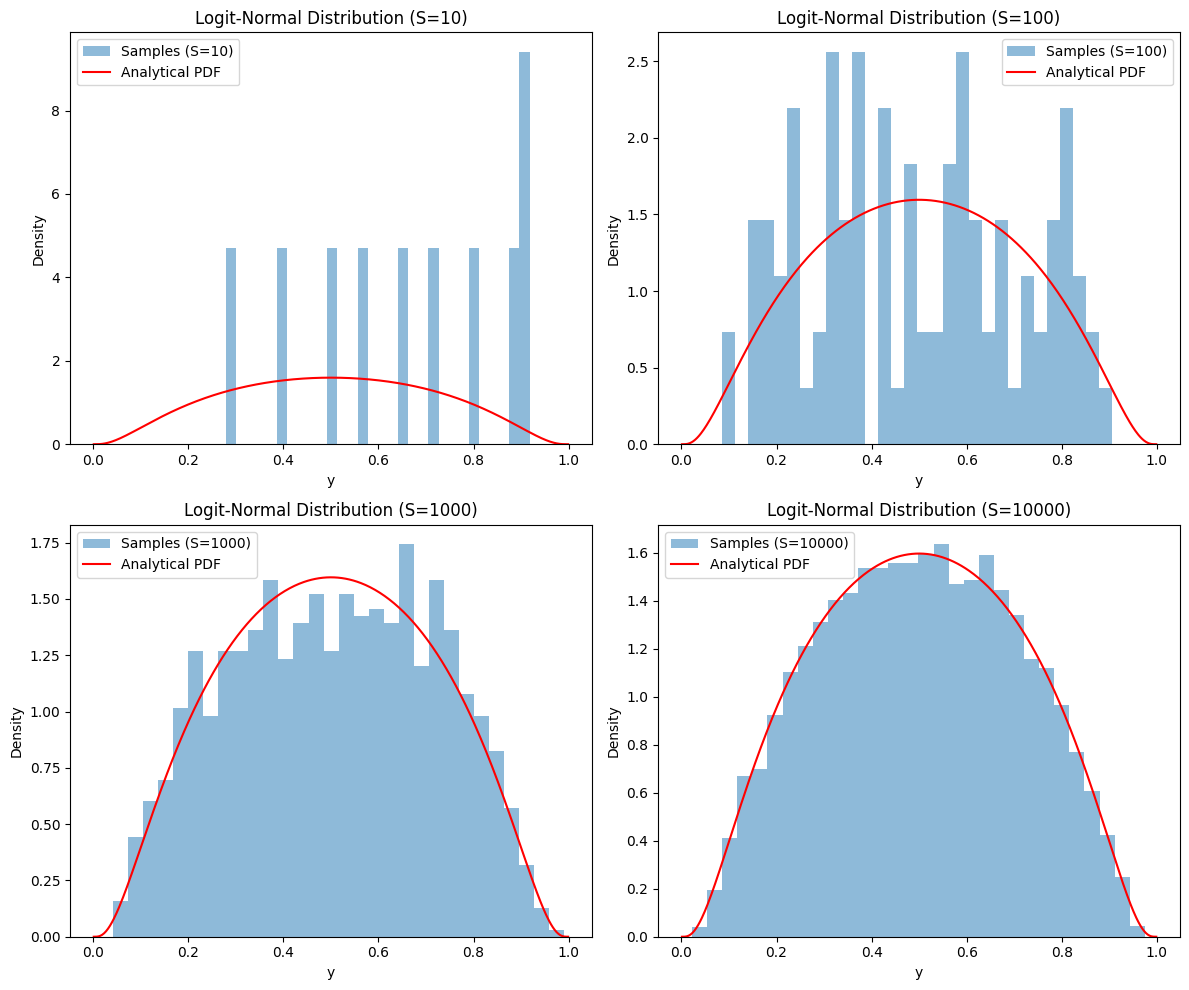

In [14]:
sample_sizes = [10, 100, 1000, 10000]

# Create a grid for y in the interval (0,1) for plotting the analytical PDF
y_vals = np.linspace(0.001, 0.999, 500)
pdf_vals = pdf_logistic(y_vals)

# Prepare subplots for part (d): multiple sample sizes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, S in enumerate(sample_sizes):

    x_samples = np.random.randn(S)
    y_samples = 1 / (1 + np.exp(-x_samples))

    axes[i].hist(y_samples, bins=30, density=True, alpha=0.5, label=f'Samples (S={S})')
    # Overlay analytical PDF
    axes[i].plot(y_vals, pdf_vals, 'r-', label='Analytical PDF')
    axes[i].set_xlabel('y')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Logit-Normal Distribution (S={S})')
    axes[i].legend()

plt.tight_layout()
plt.show()

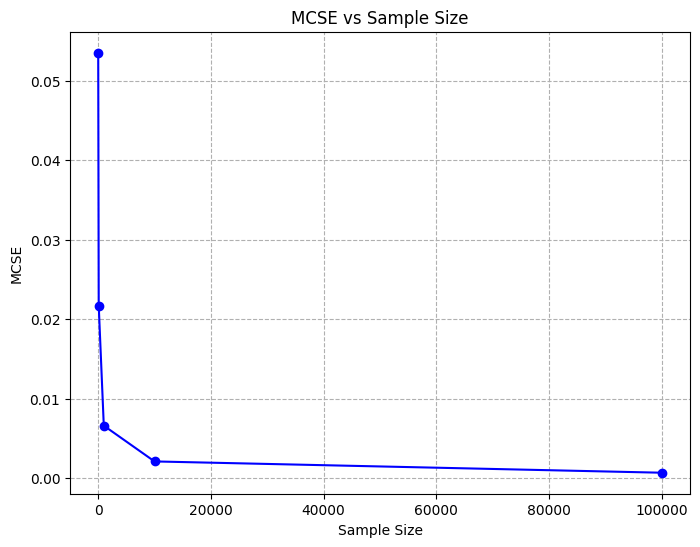

In [12]:
# Part (e): Plot MCSE vs sample size

sample_sizes = [10, 100, 1000, 10000, 100000]

# To store MCSE values for part (e)
mcse_values = []


for i, S in enumerate(sample_sizes):

    x_samples = np.random.randn(S)
    y_samples = 1 / (1 + np.exp(-x_samples))

    sample_std = np.std(y_samples, ddof=1)

    mcse = sample_std / np.sqrt(S)
    mcse_values.append(mcse)

plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, mcse_values, marker='o', linestyle='-', color='blue')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Sample Size')
plt.ylabel('MCSE')
plt.title('MCSE vs Sample Size')
plt.grid(True, which="both", ls="--")
plt.show()

## 2. LCS Generators

### Conditions for Maximum Period (Hull-Dobell Theorem)

To achieve the **full period** (i.e., maximum cycle length = `m`) in a Linear Congruential Sequence Generator, the following **Hull-Dobell Theorem** conditions must **all** be satisfied:

1. **`c` and `m` are coprime**  

2. **`a - 1` is divisible by all prime factors of `m`**

3. **If `m` is divisible by 4, then `a - 1` must also be divisible by 4**


In [10]:
def lcg(x, a, c, m):

    return (a * x + c) % m

def find_period(a, c, m, x0):

    seen = {}          # A dictionary to track when each value was first seen
    x = x0
    count = 0
    while x not in seen:
        seen[x] = count       # Record when 'x' was first seen
        x = lcg(x, a, c, m)
        count += 1

    period = count - seen[x]  # period = index when repeated - first occurrence index
    #print(seen)
    return period, x


a = 5        # Multiplier
c = 3        # Increment
m = 2**4     # A small modulus
x0 = 3       # Seed

period, first_repeat = find_period(a, c, m, x0)
print("The period of the LCG is:", period)
print("The first repeated value is:", first_repeat)


The period of the LCG is: 16
The first repeated value is: 3


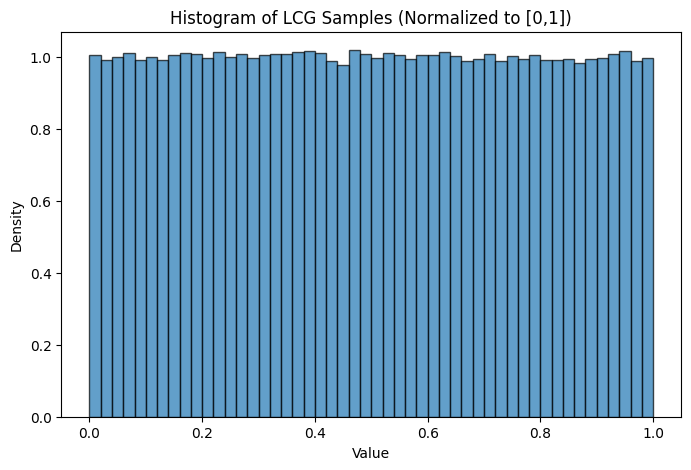

In [15]:
def lcg(x, a, c, m):

    return (a * x + c) % m


m = 2**16
a = 25173
c = 13849
seed = 1


N = 100000
x = seed
samples = []

for i in range(N):
    x = lcg(x, a, c, m)
    samples.append(x / m)


plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of LCG Samples (Normalized to [0,1])")
plt.show()
